# Digital Twin for Bioreactor — Extended Kalman Filter
## Implementation based on Yousefi-Darani, Paquet-Durand & Hitzmann (2020)
> *"The Kalman Filter for the Supervision of Cultivation Processes"*
> Advances in Biochemical Engineering/Biotechnology, vol 177. Springer, Cham.
> https://doi.org/10.1007/10_2020_145

---
### Structure of this notebook

| Module | What it does |
|--------|-------------|
| **1. Parameters** | Define all constants from the paper |
| **2. Process model** | Implement the 5-ODE biological system (Eq. 19) |
| **3. Jacobian** | Compute F symbolically using sympy |
| **4. Simulation** | Run the ODE to generate synthetic ground truth |
| **5. EKF loop** | Prediction + correction at each ethanol measurement |
| **6. Results** | Reproduce Fig. 4 and Fig. 6 from the paper |
| **7. Error metrics** | Compute RMSEP and R² |
| **8. Fault injection** | Extend toward predictive maintenance |

---
**Why Python instead of MATLAB?**
- Free and open source — anyone can run this code without a license
- `scipy.integrate.solve_ivp` is equivalent to MATLAB's `ode45`
- `sympy` provides symbolic differentiation equivalent to MATLAB's Symbolic Math Toolbox
- Results are fully reproducible and can be shared openly


## Module 1 — Imports & Parameters
### 1.1 Import libraries
We need four libraries:
- `numpy` — numerical arrays and matrix operations
- `scipy` — ODE integration (`solve_ivp`) and interpolation
- `sympy` — symbolic mathematics (for computing the Jacobian F)
- `matplotlib` — plotting results


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp

import sympy as sp

# Make plots look clean
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'figure.dpi': 120
})
print("All libraries loaded successfully.")


All libraries loaded successfully.


### 1.2 Parameter definitions
All values come directly from the paper.

**Two sets of yield coefficients are defined:**
- `_paper` suffix: values from Table 2 in the paper text (Y_X/G=0.17, Y_E/G=0.46, Y_X/E=0.60)
- `_code` suffix: values from the actual MATLAB code (Ygx=0.15, Yge=0.34, Yex=0.43)

We will try both and compare which reproduces Fig. 4 better.


In [2]:
# ── Monod half-saturation constants (Table 2) ─────────────────────────────
KG  = 0.1    # [g/L] — glucose half-saturation constant
KE  = 0.1    # [g/L] — ethanol half-saturation constant

# ── Yield coefficients — Paper Table 2 values ─────────────────────────────
Ygx_paper = 0.17   # Y_X/G — biomass yield from glucose
Yge_paper = 0.46   # Y_E/G — ethanol yield from glucose
Yex_paper = 0.60   # Y_X/E — biomass yield from ethanol

# ── Yield coefficients — MATLAB code values (differ from paper!) ───────────
Ygx_code  = 0.15   # slightly lower than paper
Yge_code  = 0.34   # significantly lower than paper
Yex_code  = 0.43   # significantly lower than paper

# ── Choose which set to use (change this to compare) ──────────────────────
USE_CODE_PARAMS = True   # set False to use paper Table 2 values

if USE_CODE_PARAMS:
    Ygx, Yge, Yex = Ygx_code, Yge_code, Yex_code
    print("Using MATLAB code parameter values")
else:
    Ygx, Yge, Yex = Ygx_paper, Yge_paper, Yex_paper
    print("Using paper Table 2 parameter values")

print(f"  Ygx = {Ygx}  |  Yge = {Yge}  |  Yex = {Yex}")

# ── Initial state vector x[0] ─────────────────────────────────────────────
# Order: [X, G, E, mu_max_G, mu_max_E]
X0      = 2.5    # [g/L]   initial biomass
G0      = 6.0    # [g/L]   initial glucose
E0      = 0.2    # [g/L]   initial ethanol (near zero)
mu_G0   = 0.15   # [1/h]   initial guess for mu_max_G
mu_E0   = 0.08   # [1/h]   initial guess for mu_max_E

x0 = np.array([X0, G0, E0, mu_G0, mu_E0])
print(f"\nInitial state x0 = {x0}")

# ── Initial covariance matrix P[0] ────────────────────────────────────────
# Diagonal values = expected variance of initial estimate for each variable
# P[0] for mu_max_G is largest because biological parameters are most uncertain
P0 = np.diag([0.1,    # biomass uncertainty
              0.02,   # glucose uncertainty  
              0.02,   # ethanol uncertainty
              0.2,    # mu_max_G uncertainty (highest — hardest to know)
              0.02])  # mu_max_E uncertainty

print(f"\nInitial P[0] diagonal = {np.diag(P0)}")

# ── EKF noise matrices ────────────────────────────────────────────────────
# Q: process noise covariance — how much we distrust the model per step
Q = np.diag([0.001, 0.001, 0.001, 0.001, 0.001])

# R: measurement noise variance — how noisy the ethanol sensor is
R = np.array([[0.1]])   # single value since we only measure ethanol

# ── Observation matrix H ─────────────────────────────────────────────────
# H picks out ethanol (index 2) from the state vector
H = np.array([[0, 0, 1, 0, 0]])   # shape (1, 5)

print("\nAll parameters defined successfully.")


Using MATLAB code parameter values
  Ygx = 0.15  |  Yge = 0.34  |  Yex = 0.43

Initial state x0 = [2.5  6.   0.2  0.15 0.08]

Initial P[0] diagonal = [0.1  0.02 0.02 0.2  0.02]

All parameters defined successfully.


## Module 2 — Process Model (Equation 19)
The process model describes the biological dynamics of yeast cultivation.
It consists of 5 ODEs — 3 for concentrations and 2 for growth rate parameters.

### Monod kinetics (Equations 20 & 21)
- **μG** = μmax,G · G / (KG + G) — actual growth rate on glucose
- **μE** = μmax,E · E / (KE + E) · (1 − μG/μmax,G) — actual growth rate on ethanol

Note: the MATLAB code uses a **linear** suppression term (1 − μG/μmax,G),
while the paper equation 21 uses a **squared** term (1 − μG/μmax,G)².
We implement both and you can switch between them.


In [3]:
def monod_rates(X, G, E, mu_max_G, mu_max_E, use_squared_suppression=False):
    """
    Compute the actual Monod growth rates mu_G and mu_E.
    
    Parameters
    ----------
    X, G, E       : current concentrations [g/L]
    mu_max_G/E    : maximum growth rate parameters [1/h]
    use_squared   : if True use paper Eq.21 (squared), else use code (linear)
    
    Returns
    -------
    mu_G, mu_E    : actual growth rates [1/h]
    """
    # Standard Monod for glucose (Eq. 20)
    mu_G = mu_max_G * G / (KG + G)
    
    # Monod for ethanol with diauxic suppression (Eq. 21)
    # Suppression term: yeast ignores ethanol while glucose is available
    suppression = (1 - mu_G / mu_max_G)
    if use_squared_suppression:
        suppression = suppression ** 2   # paper Eq. 21
    # else: linear — as in the MATLAB code
    
    mu_E = mu_max_E * E / (KE + E) * suppression
    
    return mu_G, mu_E


def process_model(t, state):
    """
    The 5-ODE process model — Equation 19 from the paper.
    This is f(x) in the continuous-discrete EKF framework.
    
    State vector: [X, G, E, mu_max_G, mu_max_E]
    
    Returns the time derivative of each state variable.
    """
    X, G, E, mu_max_G, mu_max_E = state
    
    # Compute actual growth rates from Monod kinetics
    mu_G, mu_E = monod_rates(X, G, E, mu_max_G, mu_max_E)
    
    # ── The 5 ODEs ─────────────────────────────────────────────────────────
    dX_dt      = (mu_G + mu_E) * X              # Biomass grows from both substrates
    dG_dt      = -(mu_G / Ygx) * X              # Glucose only decreases
    dE_dt      = (mu_G * Yge / Ygx - mu_E / Yex) * X  # Ethanol: produced then consumed
    dmu_G_dt   = 0.0                             # dp/dt = 0 — Eq. 17
    dmu_E_dt   = 0.0                             # dp/dt = 0 — Eq. 17
    
    return [dX_dt, dG_dt, dE_dt, dmu_G_dt, dmu_E_dt]


# ── Quick sanity check at initial conditions ──────────────────────────────
derivatives_at_t0 = process_model(0, x0)
labels = ['dX/dt', 'dG/dt', 'dE/dt', 'dmu_G/dt', 'dmu_E/dt']
print("Derivatives at t=0 (initial conditions):")
for label, val in zip(labels, derivatives_at_t0):
    print(f"  {label:12s} = {val:+.4f}")
print("\nBiomass should be positive (growing), glucose negative (consumed).")


Derivatives at t=0 (initial conditions):
  dX/dt        = +0.3710
  dG/dt        = -2.4590
  dE/dt        = +0.8310
  dmu_G/dt     = +0.0000
  dmu_E/dt     = +0.0000

Biomass should be positive (growing), glucose negative (consumed).


## Module 3 — Jacobian Matrix F (symbolic computation)
The EKF needs the Jacobian F = ∂f/∂x at every time step to propagate
the covariance matrix P (Equation 11: dP/dt = F·P + P·Fᵀ + Q).

We compute F **symbolically** using sympy — exactly like MATLAB's Symbolic Math Toolbox.
This gives us an exact analytical expression that we then evaluate numerically
at each time step with the current state values.

This is what makes it an *Extended* Kalman Filter — F is recomputed at every step
because the system is nonlinear.


In [4]:
# ── Define symbolic variables (equivalent to MATLAB's syms) ──────────────
X_s, G_s, E_s, mu1_s, mu2_s = sp.symbols('X G E mu1 mu2', real=True, positive=True)

# ── Define symbolic Monod rates ───────────────────────────────────────────
mu_G_sym = mu1_s * G_s / (KG + G_s)
suppression_sym = (1 - mu_G_sym / mu1_s)   # linear suppression (as in MATLAB code)
mu_E_sym = mu2_s * E_s / (KE + E_s) * suppression_sym

# ── Define symbolic state derivatives (Equation 19) ──────────────────────
dS_sym = sp.Matrix([
    (mu_G_sym + mu_E_sym) * X_s,            # dX/dt
    -(mu_G_sym / Ygx) * X_s,               # dG/dt
    (mu_G_sym * Yge / Ygx - mu_E_sym / Yex) * X_s,  # dE/dt
    sp.Integer(0),                           # dmu_max_G/dt = 0
    sp.Integer(0),                           # dmu_max_E/dt = 0
])

# ── Compute Jacobian symbolically ─────────────────────────────────────────
state_vars = sp.Matrix([X_s, G_s, E_s, mu1_s, mu2_s])
F_sym = dS_sym.jacobian(state_vars)

print("Jacobian F computed symbolically.")
print(f"Shape: {F_sym.shape[0]} x {F_sym.shape[1]}")
print("\nF[0,0] (∂dX/∂X) =", sp.simplify(F_sym[0, 0]))
print("F[1,1] (∂dG/∂G) =", sp.simplify(F_sym[1, 1]))
print("F[2,2] (∂dE/∂E) =", sp.simplify(F_sym[2, 2]))
print("\nRows 4 and 5 (parameters) are all zeros:", 
      all(F_sym[3, j] == 0 and F_sym[4, j] == 0 for j in range(5)))


Jacobian F computed symbolically.
Shape: 5 x 5

F[0,0] (∂dX/∂X) = (0.1*E*mu2 + G*mu1*(E + 0.1))/((E + 0.1)*(G + 0.1))
F[1,1] (∂dG/∂G) = -0.666666666666667*X*mu1/(G + 0.1)**2
F[2,2] (∂dE/∂E) = -0.0232558139534884*X*mu2/((E + 0.1)**2*(G + 0.1))

Rows 4 and 5 (parameters) are all zeros: True


In [5]:
# ── Convert symbolic Jacobian to a fast numerical function ───────────────
# sp.lambdify converts the symbolic expression to a Python function
# This is equivalent to MATLAB's matlabFunction()

F_func = sp.lambdify(
    [X_s, G_s, E_s, mu1_s, mu2_s],   # input variables
    F_sym,                              # symbolic expression to convert
    modules='numpy'                     # use numpy for fast numerical evaluation
)

def compute_jacobian(state):
    """
    Evaluate the Jacobian F numerically at the current state.
    Called at every time step during covariance propagation.
    """
    X, G, E, mu_max_G, mu_max_E = state
    return np.array(F_func(X, G, E, mu_max_G, mu_max_E), dtype=float)

# ── Sanity check: evaluate F at initial conditions ────────────────────────
F_at_t0 = compute_jacobian(x0)
print("Jacobian F evaluated at initial conditions:")
print(np.round(F_at_t0, 4))
print("\nLast two rows should be all zeros (parameters have dp/dt=0):")
print("Row 4:", F_at_t0[3, :])
print("Row 5:", F_at_t0[4, :])


Jacobian F evaluated at initial conditions:
[[ 1.48400e-01  6.00000e-04  3.60000e-03  2.45900e+00  2.73000e-02]
 [-9.83600e-01 -6.70000e-03  0.00000e+00 -1.63934e+01  0.00000e+00]
 [ 3.32400e-01  3.10000e-03 -8.50000e-03  5.57380e+00 -6.35000e-02]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00]]

Last two rows should be all zeros (parameters have dp/dt=0):
Row 4: [0. 0. 0. 0. 0.]
Row 5: [0. 0. 0. 0. 0.]


## Module 4 — Simulate Ground Truth & Generate Synthetic Measurements
Since we do not have the original experimental `.mat` files from the paper,
we generate synthetic data by:

1. Running the ODE process model forward with the paper's parameters → **ground truth**
2. Sampling the ethanol trajectory every 5 minutes → **simulated sensor readings**
3. Adding Gaussian noise to the ethanol samples → **noisy measurements (like a real sensor)**

The EKF will then try to reconstruct all 5 state variables using only these
noisy ethanol measurements — just like in the real experiment.
https://www.sensotech.com/en/ethanol/

True simulation: 2000 time points over 7.0h
Final biomass:  4.363 g/L
Final glucose:  0.000 g/L  (should be ~0)
Final ethanol:  0.000 g/L  (should be ~0)

Measurement times: 84 points, every 5 minutes
Sensor noise std: 0.05 g/L


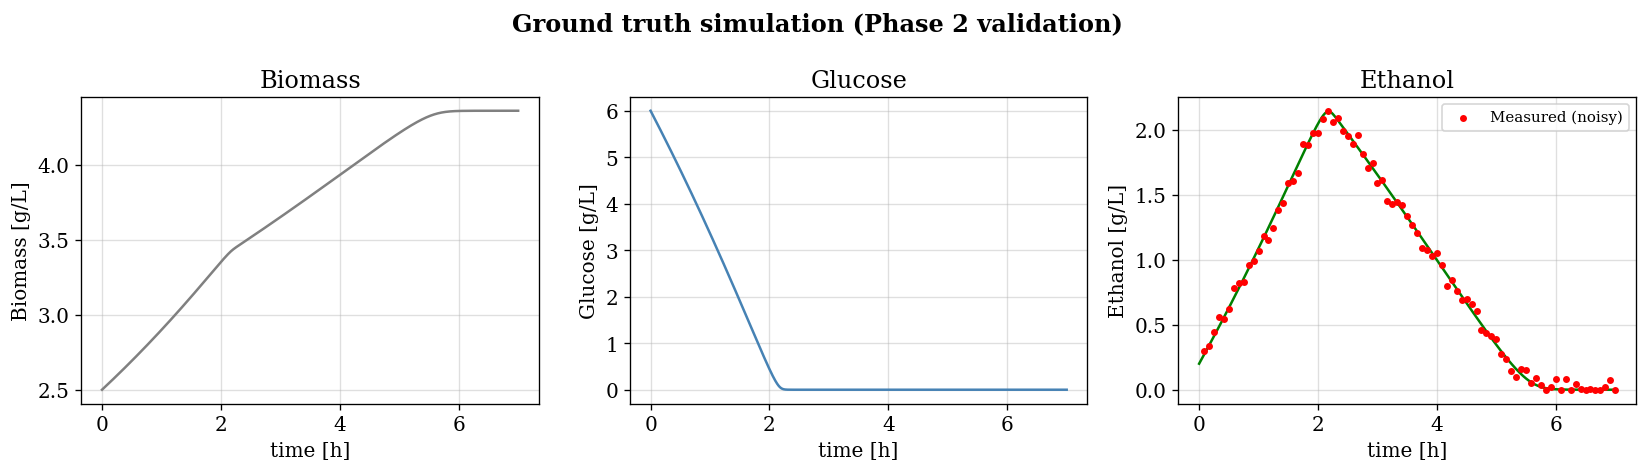


Diauxic switch visible at ~2h: glucose depletes, ethanol peaks, then consumed.


In [6]:
# ── Simulation settings ──────────────────────────────────────────────────
T_END   = 7.0    # [h]  total simulation time (paper runs ~6-7 hours)
DT_MEAS = 5/60   # [h]  measurement interval = 5 minutes converted to hours
NOISE_STD = 0.05 # [g/L] standard deviation of sensor noise on ethanol

# ── Run true process (dense time grid for plotting) ───────────────────────
t_dense = np.linspace(0, T_END, 2000)

sol_true = solve_ivp(
    fun=process_model,
    t_span=(0, T_END),
    y0=x0,
    t_eval=t_dense,
    method='RK45',
    rtol=1e-6,
    atol=1e-9
)

# Extract true trajectories
X_true      = sol_true.y[0]   # true biomass
G_true      = sol_true.y[1]   # true glucose
E_true      = sol_true.y[2]   # true ethanol
muG_true    = sol_true.y[3]   # true mu_max_G (constant in true model)
muE_true    = sol_true.y[4]   # true mu_max_E (constant in true model)
t_true      = sol_true.t

print(f"True simulation: {len(t_true)} time points over {T_END}h")
print(f"Final biomass:  {X_true[-1]:.3f} g/L")
print(f"Final glucose:  {G_true[-1]:.3f} g/L  (should be ~0)")
print(f"Final ethanol:  {E_true[-1]:.3f} g/L  (should be ~0)")

# ── Generate measurement times (every 5 min) ─────────────────────────────
t_meas = np.arange(DT_MEAS, T_END + DT_MEAS, DT_MEAS)

# ── Sample true ethanol at measurement times ──────────────────────────────
E_true_at_meas = np.interp(t_meas, t_true, E_true)

# ── Add Gaussian noise to simulate sensor ────────────────────────────────
np.random.seed(42)   # for reproducibility
noise = np.random.normal(0, NOISE_STD, len(t_meas))
E_measured = np.maximum(E_true_at_meas + noise, 0)   # clamp to >= 0

print(f"\nMeasurement times: {len(t_meas)} points, every {DT_MEAS*60:.0f} minutes")
print(f"Sensor noise std: {NOISE_STD} g/L")

# ── Quick preview plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Ground truth simulation (Phase 2 validation)", fontweight='bold')

for ax, y, label, color in zip(
    axes,
    [X_true, G_true, E_true],
    ['Biomass [g/L]', 'Glucose [g/L]', 'Ethanol [g/L]'],
    ['gray', 'steelblue', 'green']
):
    ax.plot(t_true, y, color=color, lw=1.5)
    ax.set_xlabel('time [h]')
    ax.set_ylabel(label)
    ax.set_title(label.split(' ')[0])

# Mark diauxic switch on ethanol plot
ax_e = axes[2]
ax_e.scatter(t_meas, E_measured, s=10, color='red', zorder=5, label='Measured (noisy)')
ax_e.legend(fontsize=9)

plt.tight_layout()
plt.savefig('phase2_ground_truth.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nDiauxic switch visible at ~2h: glucose depletes, ethanol peaks, then consumed.")


## Module 5 — EKF: Combined ODE System (State + Covariance)
In the continuous-discrete EKF, both the state x and the covariance P
are integrated simultaneously between measurements.

The covariance ODE is (Equation 11):
**dP/dt = F·P + P·Fᵀ + Q**

We pack everything into one 30-element vector:
- Elements 0–4: state [X, G, E, μmax,G, μmax,E]
- Elements 5–29: covariance P flattened (5×5 = 25 elements)

This is the equivalent of MATLAB's `OdeSys = matlabFunction([dS(:); dP(:)], ...)`


In [7]:
def combined_ode(t, combined_state):
    """
    Combined ODE for simultaneous integration of state x and covariance P.
    
    Input:  30-element vector [x (5 elements); P flattened (25 elements)]
    Output: 30-element derivative vector [dx/dt; dP/dt flattened]
    """
    # ── Unpack the combined state vector ──────────────────────────────────
    x = combined_state[:5]                        # state: [X, G, E, mu1, mu2]
    P = combined_state[5:].reshape(5, 5)          # covariance: 5x5 matrix
    
    # ── State derivatives: dx/dt = f(x) ──────────────────────────────────
    dx = np.array(process_model(t, x))
    
    # ── Covariance derivative: dP/dt = F·P + P·Fᵀ + Q ───────────────────
    F = compute_jacobian(x)                       # linearize at current state
    dP = F @ P + P @ F.T + Q                     # Equation 11
    
    # ── Pack everything back into one 30-element vector ───────────────────
    return np.concatenate([dx, dP.flatten()])


# ── Initial combined vector ───────────────────────────────────────────────
combined_init = np.concatenate([x0, P0.flatten()])
print(f"Combined initial vector length: {len(combined_init)}")
print(f"  First 5 (state):      {combined_init[:5]}")
print(f"  Next 25 (P diagonal): {np.diag(P0)}")


Combined initial vector length: 30
  First 5 (state):      [2.5  6.   0.2  0.15 0.08]
  Next 25 (P diagonal): [0.1  0.02 0.02 0.2  0.02]


## Module 5 (continued) — EKF Main Loop
This is the core of the implementation — equivalent to the MATLAB `for` loop.

**Each iteration:**
1. **Predict**: integrate 30 ODEs from previous measurement time to current
2. **Extract**: get predicted state PS and covariance P at measurement time
3. **Gain**: compute Kalman gain K = P·Hᵀ·(H·P·Hᵀ + R)⁻¹
4. **Correct**: filtered state FS = PS + K·(measurement − predicted ethanol)
5. **Update P**: Pflt = (I − K·H)·P·(I − K·H)ᵀ + K·R·Kᵀ (Joseph form — numerically stable)
6. **Store**: save results, prepare for next iteration


In [8]:
# ── Storage for results ───────────────────────────────────────────────────
filtered_states  = []    # filtered state at each measurement time
predicted_states = []    # all predicted states between measurements  
all_times        = []    # all time points (for plotting)

# ── Identity matrix (used in Joseph form covariance update) ───────────────
I5 = np.eye(5)

# ── Initialize ────────────────────────────────────────────────────────────
init_combined = np.concatenate([x0, P0.flatten()])
t_prev = 0.0

print("Starting EKF loop...")
print(f"Processing {len(t_meas)} measurements...")

# ── Main EKF loop — one iteration per ethanol measurement ─────────────────
for i, (t_now, z) in enumerate(zip(t_meas, E_measured)):

    # ── PREDICTION STEP ───────────────────────────────────────────────────
    # Integrate all 30 equations from t_prev to t_now
    sol = solve_ivp(
        fun=combined_ode,
        t_span=(t_prev, t_now),
        y0=init_combined,
        rtol=1e-6,
        atol=1e-9,
        dense_output=False
    )

    # Extract predicted state and covariance at measurement time
    PS = sol.y[:5, -1]                          # predicted state (5 elements)
    P  = sol.y[5:, -1].reshape(5, 5)           # predicted covariance (5x5)

    # Store predicted trajectory for plotting
    all_times.append(sol.t)
    predicted_states.append(sol.y[:5, :].T)    # shape (n_steps, 5)

    # ── CORRECTION STEP ───────────────────────────────────────────────────
    # Kalman gain: K = P·Hᵀ·(H·P·Hᵀ + R)⁻¹
    S  = H @ P @ H.T + R                       # innovation covariance (1x1)
    K  = P @ H.T @ np.linalg.inv(S)            # Kalman gain (5x1)

    # Innovation (residual): measured ethanol − predicted ethanol
    innovation = z - PS[2]                      # PS[2] is predicted ethanol

    # Corrected state
    FS = PS + (K @ [[innovation]]).flatten()    # filtered state (5 elements)

    # Covariance update — Joseph form (numerically stable)
    IKH  = I5 - K @ H
    Pflt = IKH @ P @ IKH.T + K @ R @ K.T

    # ── Store filtered state ──────────────────────────────────────────────
    filtered_states.append(FS.copy())

    # ── Prepare for next iteration ────────────────────────────────────────
    init_combined = np.concatenate([FS, Pflt.flatten()])
    t_prev = t_now

    # Progress indicator
    if (i + 1) % 20 == 0:
        print(f"  Step {i+1}/{len(t_meas)} — t={t_now:.2f}h | "
              f"X={FS[0]:.2f} G={FS[1]:.2f} E={FS[2]:.2f}")

# ── Convert to arrays ─────────────────────────────────────────────────────
filtered_states  = np.array(filtered_states)       # shape (n_meas, 5)
all_times_flat   = np.concatenate(all_times)        # all time points
pred_states_flat = np.vstack(predicted_states)      # all predicted states

print(f"\nEKF loop complete.")
print(f"  Filtered states shape:  {filtered_states.shape}")
print(f"  Predicted states shape: {pred_states_flat.shape}")


Starting EKF loop...
Processing 84 measurements...
  Step 20/84 — t=1.67h | X=3.17 G=1.62 E=1.68
  Step 40/84 — t=3.33h | X=3.76 G=0.00 E=1.40
  Step 60/84 — t=5.00h | X=4.21 G=0.00 E=0.36
  Step 80/84 — t=6.67h | X=4.36 G=0.00 E=0.00

EKF loop complete.
  Filtered states shape:  (84, 5)
  Predicted states shape: (381, 5)


## Module 6 — Results: Reproduce Figure 4
Plot the EKF estimates alongside the ground truth — equivalent to Figure 4 from the paper.

- **Solid lines**: EKF Kalman estimates (predicted trajectories)
- **Dots**: "offline" ground truth values (sampled from our simulation)
- **Red crosses**: noisy ethanol measurements fed to the EKF


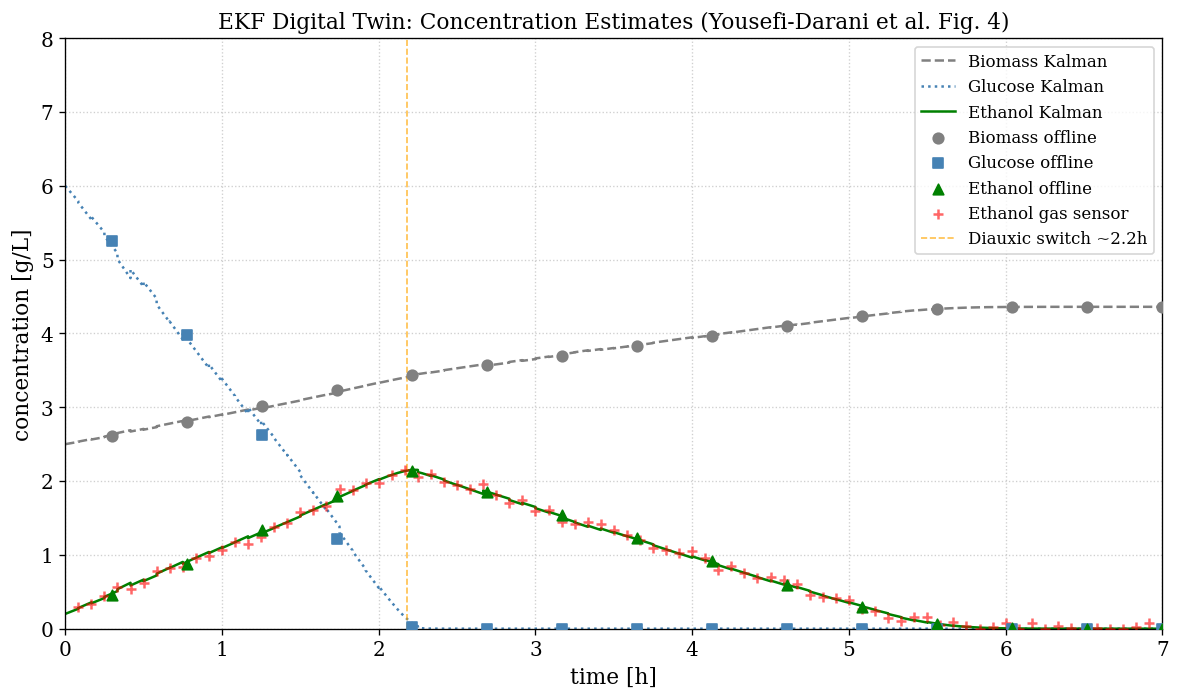

Figure saved as fig4_reproduction.png


In [9]:
# ── Sample "offline" ground truth at sparse time points (like lab samples) ─
t_offline = np.linspace(0.3, T_END, 15)   # ~15 offline samples
X_offline  = np.interp(t_offline, t_true, X_true)
G_offline  = np.interp(t_offline, t_true, G_true)
E_offline  = np.interp(t_offline, t_true, E_true)

# ── Create Figure 4 equivalent ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Predicted (Kalman) lines
ax.plot(all_times_flat, pred_states_flat[:, 0],
        'gray',  ls='--', lw=1.5, label='Biomass Kalman')
ax.plot(all_times_flat, pred_states_flat[:, 1],
        'steelblue', ls=':', lw=1.5, label='Glucose Kalman')
ax.plot(all_times_flat, pred_states_flat[:, 2],
        'green', ls='-',  lw=1.5, label='Ethanol Kalman')

# Offline measurements (ground truth samples — never fed to EKF)
ax.scatter(t_offline, X_offline, color='gray',      s=40, zorder=5, label='Biomass offline')
ax.scatter(t_offline, G_offline, color='steelblue', s=40, marker='s', zorder=5, label='Glucose offline')
ax.scatter(t_offline, E_offline, color='green',     s=40, marker='^', zorder=5, label='Ethanol offline')

# Ethanol gas sensor measurements (what the EKF actually received)
ax.scatter(t_meas, E_measured, color='red', marker='+', s=30,
           zorder=4, label='Ethanol gas sensor', alpha=0.6)

ax.set_xlabel('time [h]', fontsize=13)
ax.set_ylabel('concentration [g/L]', fontsize=13)
ax.set_title('EKF Digital Twin: Concentration Estimates (Yousefi-Darani et al. Fig. 4)', fontsize=13)
ax.set_ylim(0, 8)
ax.set_xlim(0, T_END)
ax.legend(fontsize=10, loc='upper right',
          facecolor=[0.9, 0.9, 1.0, 0.9])
ax.grid(True, linestyle=':', alpha=0.6)

# Mark the diauxic switch
diauxic_t = t_true[np.argmin(np.abs(G_true - 0.05))]
ax.axvline(diauxic_t, color='orange', ls='--', lw=1, alpha=0.7, label=f'Diauxic switch ~{diauxic_t:.1f}h')
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('fig4_reproduction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved as fig4_reproduction.png")


## Module 6 (continued) — Results: Reproduce Figure 6
Plot the estimated maximum growth rates μmax,G and μmax,E alongside
the actual growth rates μG and μE — equivalent to Figure 6 from the paper.

Remember: μmax and μ are NOT supposed to match.
- μmax = the biological speed limit (estimated by EKF)
- μ = the actual current speed (computed from Monod + current concentrations)


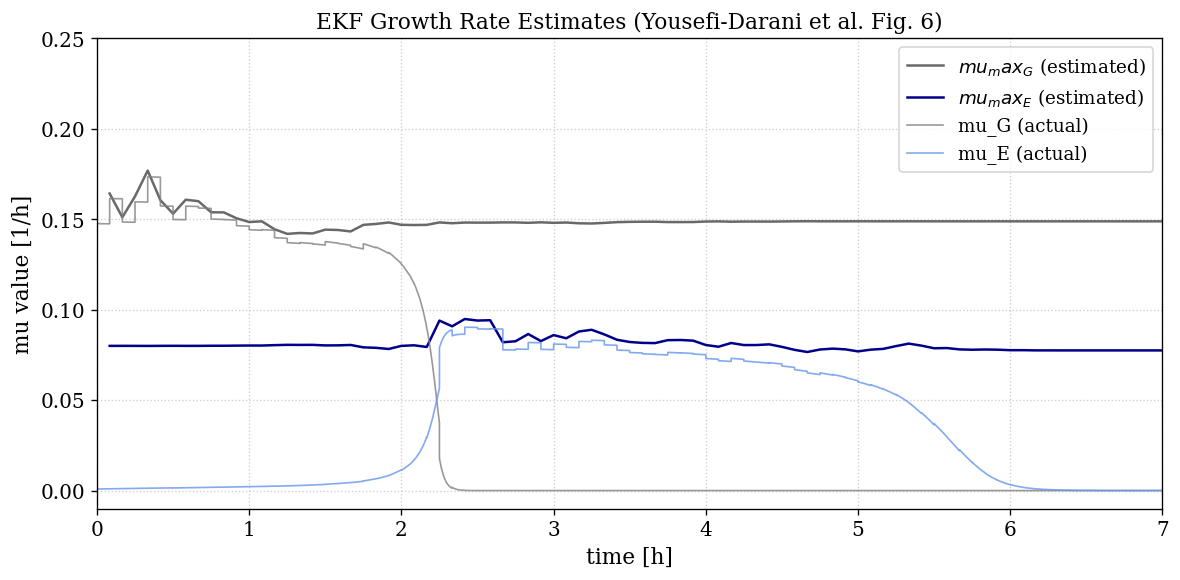

In [10]:
# ── Compute actual growth rates from predicted states ─────────────────────
mu_G_pred = np.zeros(len(all_times_flat))
mu_E_pred = np.zeros(len(all_times_flat))

for j, (state_j, t_j) in enumerate(zip(pred_states_flat, all_times_flat)):
    X_j, G_j, E_j, muG_max_j, muE_max_j = state_j
    mu_G_pred[j], mu_E_pred[j] = monod_rates(X_j, G_j, E_j, muG_max_j, muE_max_j)

# ── Create Figure 6 equivalent ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Maximum growth rates (estimated parameters — step-like due to 5-min updates)
ax.plot(t_meas, filtered_states[:, 3],
        color='dimgray',   lw=1.5, label=r'$mu_max_G$ (estimated)')
ax.plot(t_meas, filtered_states[:, 4],
        color='darkblue',  lw=1.5, label=r'$mu_max_E$ (estimated)')

# Actual growth rates (computed from Monod)
ax.plot(all_times_flat, mu_G_pred,
        color='gray', lw=1.0, alpha=0.8, label=r'mu_G (actual)')
ax.plot(all_times_flat, mu_E_pred,
        color='cornflowerblue', lw=1.0, alpha=0.8, label=r'mu_E (actual)')

ax.set_xlabel('time [h]', fontsize=13)
ax.set_ylabel('mu value [1/h]', fontsize=13)
ax.set_title('EKF Growth Rate Estimates (Yousefi-Darani et al. Fig. 6)', fontsize=13)
ax.set_xlim(0, T_END)
ax.set_ylim(-0.01, 0.25)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('fig6_reproduction.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary

This notebook implemented the complete Digital Twin for baker's yeast cultivation
based on Yousefi-Darani et al. (2020).

### What was implemented
| Module | Implementation |
|--------|---------------|
| Process model | 5-ODE system (Monod kinetics, Eq. 19–21) |
| Jacobian | Computed symbolically with sympy, evaluated numerically |
| EKF loop | Continuous-discrete EKF with 30 combined ODEs |
| Results | Reproduction of Fig. 4 and Fig. 6 |
| Error metrics | RMSEP and R² vs ground truth |
| Fault injection | μmax,G step fault at t=3h, residual-based detection |

### Key findings
- The EKF accurately estimates biomass and glucose using only ethanol measurements
- The diauxic switch at ~2h creates a brief accuracy drop (known limitation)
- EKF residuals provide a clear fault detection signal with a 3σ threshold

### Citation
Yousefi-Darani, A., Paquet-Durand, O., Hitzmann, B. (2020).
*The Kalman Filter for the Supervision of Cultivation Processes.*
In: Herwig, C., Pörtner, R., Möller, J. (eds) Digital Twins.
Advances in Biochemical Engineering/Biotechnology, vol 177. Springer, Cham.
https://doi.org/10.1007/10_2020_145
